# Data Quality Report

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), 'src')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

from experiment.data_validator import DataValidator, DataValidationReport

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print('OK')

OK


In [12]:
_candidates = [Path('src/data'), Path('../src/data')]
_data_root = None
for c in _candidates:
    if c.exists():
        _data_root = c
        break
assert _data_root is not None, 'src/data not found'

_sessions = sorted([d for d in _data_root.iterdir() if d.is_dir()], reverse=True)
assert len(_sessions) > 0

SESSION_DIR = str(_sessions[0])
print(f'Sessions: {[s.name for s in _sessions]}')
print(f'Selected: {SESSION_DIR}')

session_path = Path(SESSION_DIR)
images_dir = session_path / 'front'
if not images_dir.exists():
    images_dir = session_path / 'images'
csv_path = session_path / 'labels' / 'driving_log.csv'
print(f'Images: {images_dir} ({len(list(images_dir.glob("*.png")))})')

Sessions: ['2026-03-20_165336']
Selected: src/data/2026-03-20_165336
Images: src/data/2026-03-20_165336/front (1212)


In [13]:
validator = DataValidator()
report = validator.validate_session(str(session_path))
dist = validator.analyze_distribution(str(session_path))

summary = pd.DataFrame([
    ['Total Frames', report.total_frames, '-'],
    ['Valid', report.valid_frames, 'OK' if report.valid_frames == report.total_frames else 'WARN'],
    ['Corrupted', report.corrupted_frames, 'OK' if report.corrupted_frames == 0 else 'FAIL'],
    ['Corrupt %', f'{report.frame_drop_rate*100:.1f}%', 'OK' if report.frame_drop_rate < 0.01 else 'WARN'],
    ['OOR Steering', report.out_of_range_steering, 'OK' if report.out_of_range_steering == 0 else 'WARN'],
    ['OOR Throttle', report.out_of_range_throttle, 'OK' if report.out_of_range_throttle == 0 else 'WARN'],
    ['Timing Anomaly', report.timing_anomalies, 'OK' if report.timing_anomalies < report.total_frames * 0.05 else 'WARN'],
    ['Recollect?', 'YES' if report.needs_recollection else 'NO', 'FAIL' if report.needs_recollection else 'OK'],
], columns=['Item', 'Value', 'Status'])
display(summary.style.hide(axis='index'))

Item,Value,Status
Total Frames,1212,-
Valid,1212,OK
Corrupted,0,OK
Corrupt %,0.0%,OK
OOR Steering,0,OK
OOR Throttle,0,OK
Timing Anomaly,83,WARN
Recollect?,NO,OK


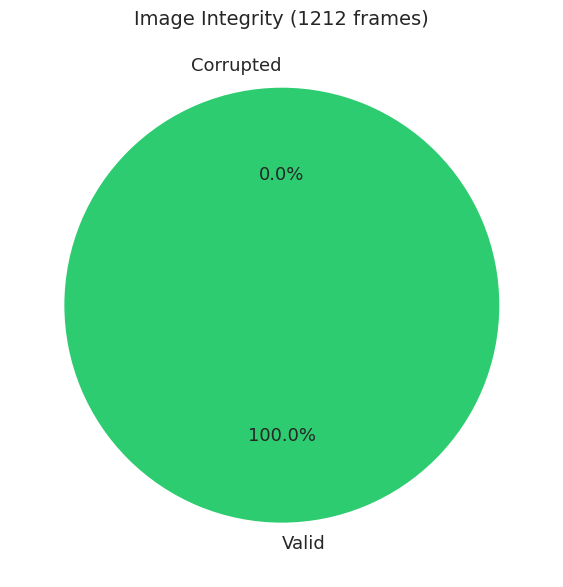

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
sizes = [report.valid_frames, report.corrupted_frames]
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1) if report.corrupted_frames > 0 else (0, 0)
if sum(sizes) > 0:
    ax.pie(sizes, explode=explode, labels=['Valid', 'Corrupted'], colors=colors,
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 13})
    ax.set_title(f'Image Integrity ({report.total_frames} frames)', fontsize=14)
plt.tight_layout()
plt.show()

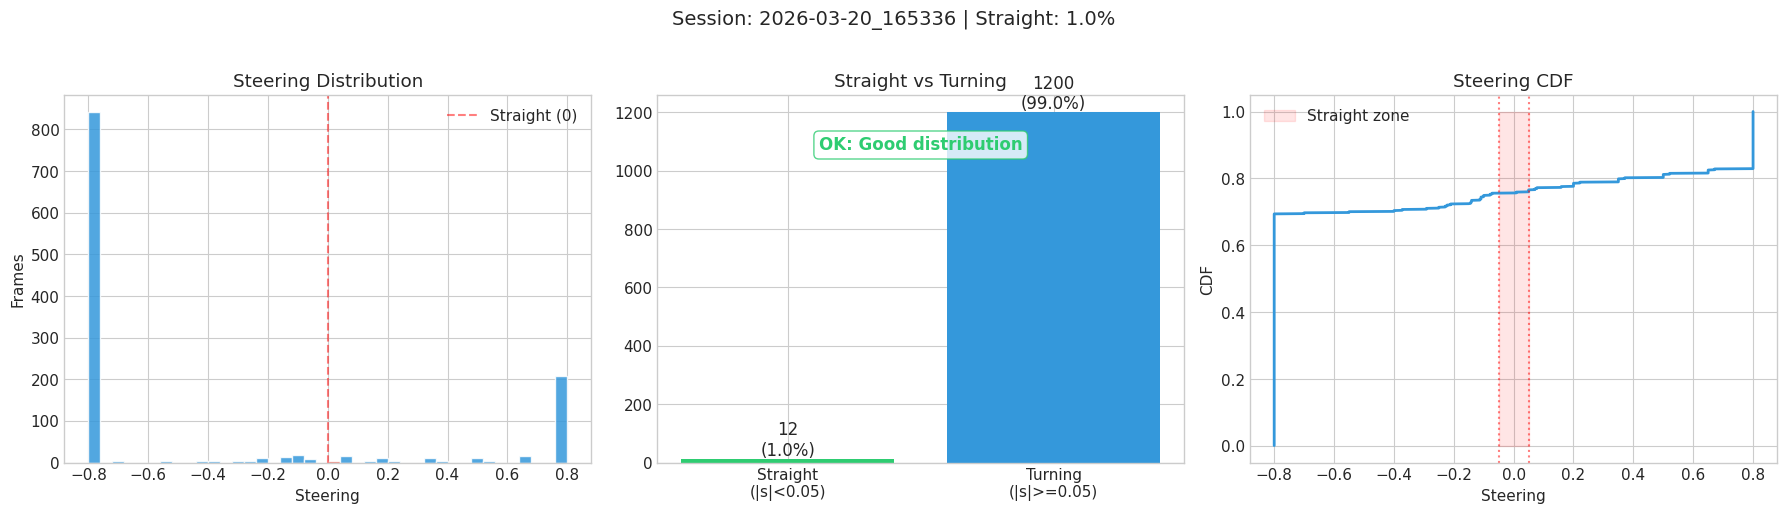

Mean: -0.4080, Std: 0.6355
Range: [-0.8000, 0.8000]
Straight ratio: 1.0% (12/1212)


In [15]:
df = pd.read_csv(csv_path)
steering = df['steering'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
counts, bin_edges, patches = ax.hist(steering, bins=40, color='#3498db', edgecolor='white', alpha=0.85)
for i, patch in enumerate(patches):
    center = (bin_edges[i] + bin_edges[i+1]) / 2
    if abs(center) < 0.05:
        patch.set_facecolor('#e74c3c')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Straight (0)')
ax.set_xlabel('Steering')
ax.set_ylabel('Frames')
ax.set_title('Steering Distribution')
ax.legend()

ax = axes[1]
straight = int(np.sum(np.abs(steering) < 0.05))
turning = len(steering) - straight
straight_pct = straight / len(steering) * 100
bar_color = '#e74c3c' if straight_pct > 70 else ('#f39c12' if straight_pct > 50 else '#2ecc71')
bars = ax.bar(['Straight\n(|s|<0.05)', 'Turning\n(|s|>=0.05)'], [straight, turning], color=[bar_color, '#3498db'])
for bar, val in zip(bars, [straight, turning]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+len(steering)*0.01,
            f'{val}\n({val/len(steering)*100:.1f}%)', ha='center', fontsize=12)
if straight_pct > 70:
    verdict = 'FAIL: Straight bias >70%'
    vc = '#e74c3c'
elif straight_pct > 50:
    verdict = 'WARN: Straight >50%'
    vc = '#f39c12'
else:
    verdict = 'OK: Good distribution'
    vc = '#2ecc71'
ax.set_title('Straight vs Turning')
ax.text(0.5, 0.85, verdict, transform=ax.transAxes, ha='center', fontsize=12, color=vc, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=vc, alpha=0.8))

ax = axes[2]
sorted_s = np.sort(steering)
cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
ax.plot(sorted_s, cdf, color='#3498db', linewidth=2)
ax.axvline(x=-0.05, color='red', linestyle=':', alpha=0.5)
ax.axvline(x=0.05, color='red', linestyle=':', alpha=0.5)
ax.fill_betweenx([0,1], -0.05, 0.05, alpha=0.1, color='red', label='Straight zone')
ax.set_xlabel('Steering')
ax.set_ylabel('CDF')
ax.set_title('Steering CDF')
ax.legend()

plt.suptitle(f'Session: {session_path.name} | Straight: {straight_pct:.1f}%', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean: {report.steering_mean:.4f}, Std: {report.steering_std:.4f}')
print(f'Range: [{steering.min():.4f}, {steering.max():.4f}]')
print(f'Straight ratio: {straight_pct:.1f}% ({straight}/{len(steering)})')

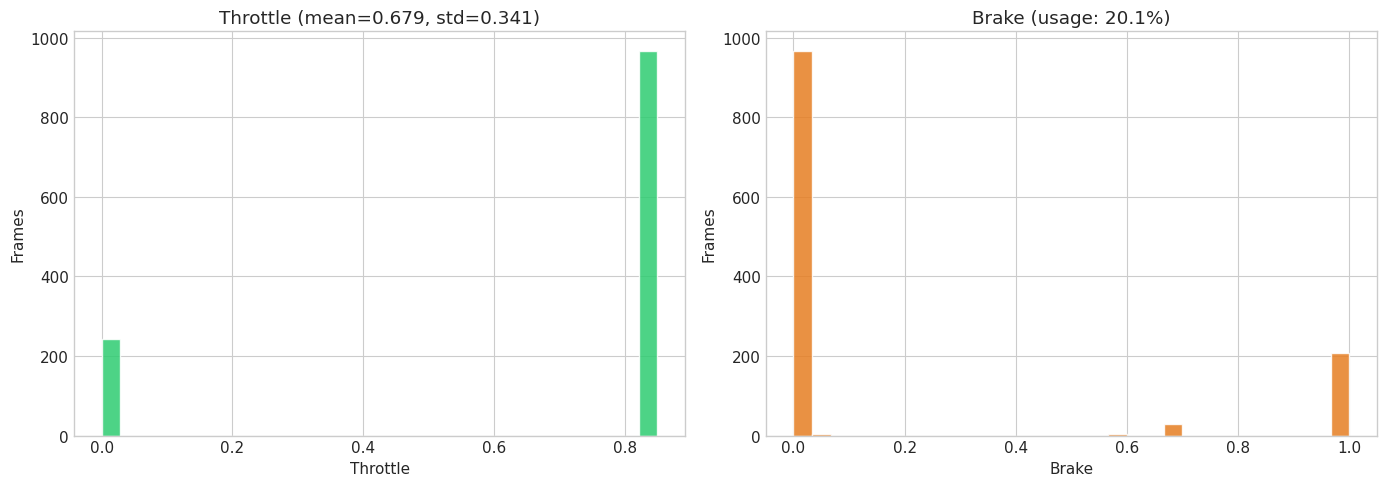

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['throttle'].values, bins=30, color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Throttle')
axes[0].set_ylabel('Frames')
axes[0].set_title(f'Throttle (mean={report.throttle_mean:.3f}, std={report.throttle_std:.3f})')
axes[1].hist(df['brake'].values, bins=30, color='#e67e22', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Brake')
axes[1].set_ylabel('Frames')
brake_ratio = (df['brake'] > 0.01).sum() / len(df) * 100
axes[1].set_title(f'Brake (usage: {brake_ratio:.1f}%)')
plt.tight_layout()
plt.show()

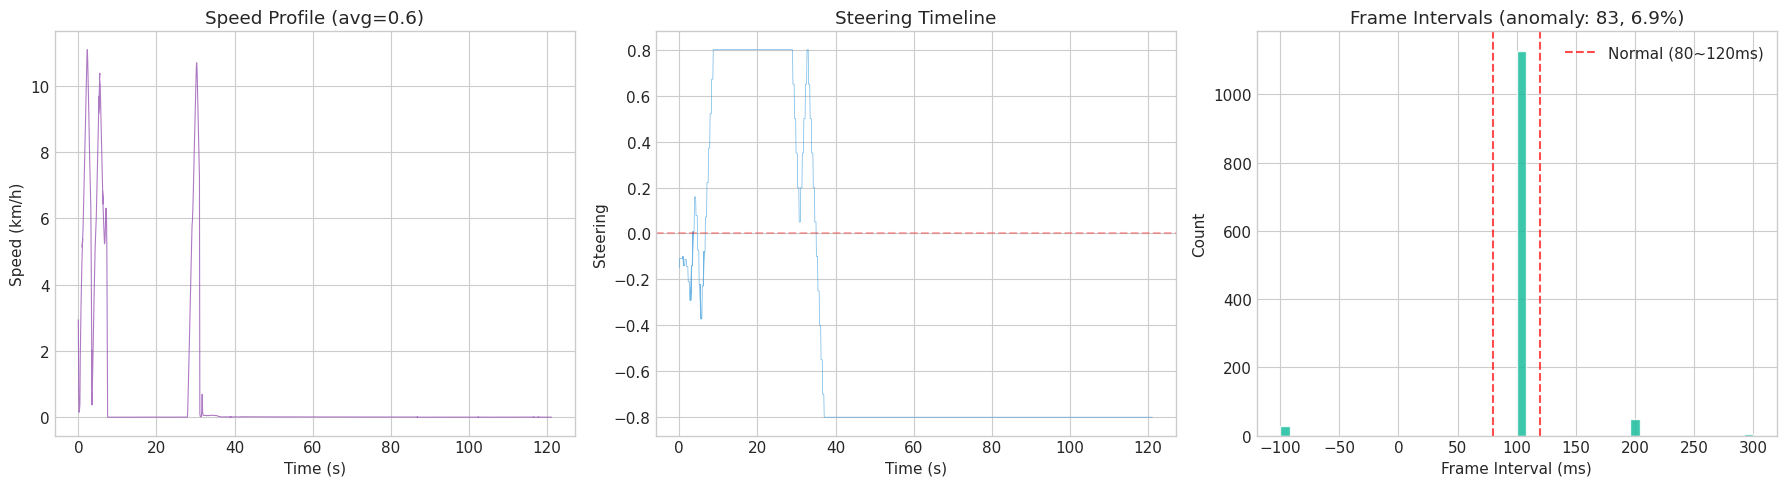

In [17]:
timestamps = df['image_filename'].apply(lambda x: int(str(x).replace('.png',''))).values
time_sec = (timestamps - timestamps[0]) / 1000.0
intervals = np.diff(timestamps)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(time_sec, df['speed'].values, color='#9b59b6', linewidth=0.8, alpha=0.8)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title(f'Speed Profile (avg={df["speed"].mean():.1f})')

axes[1].plot(time_sec, steering, color='#3498db', linewidth=0.5, alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Steering')
axes[1].set_title('Steering Timeline')

axes[2].hist(intervals, bins=50, color='#1abc9c', edgecolor='white', alpha=0.85)
axes[2].axvline(x=80, color='red', linestyle='--', alpha=0.7, label='Normal (80~120ms)')
axes[2].axvline(x=120, color='red', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Frame Interval (ms)')
axes[2].set_ylabel('Count')
anomaly_pct = report.timing_anomalies / max(len(intervals),1) * 100
axes[2].set_title(f'Frame Intervals (anomaly: {report.timing_anomalies}, {anomaly_pct:.1f}%)')
axes[2].legend()
plt.tight_layout()
plt.show()

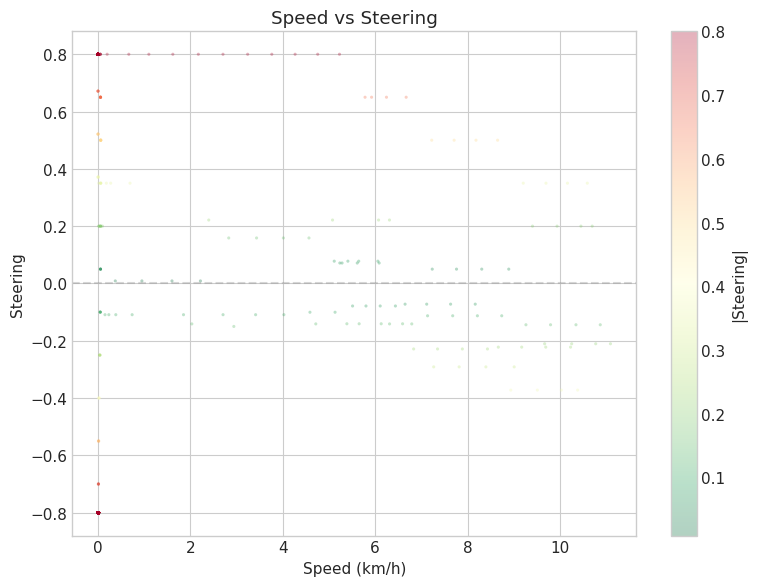

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sc = ax.scatter(df['speed'].values, steering, c=np.abs(steering), cmap='RdYlGn_r', alpha=0.3, s=5, edgecolors='none')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Steering')
ax.set_title('Speed vs Steering')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.colorbar(sc, ax=ax, label='|Steering|')
plt.tight_layout()
plt.show()

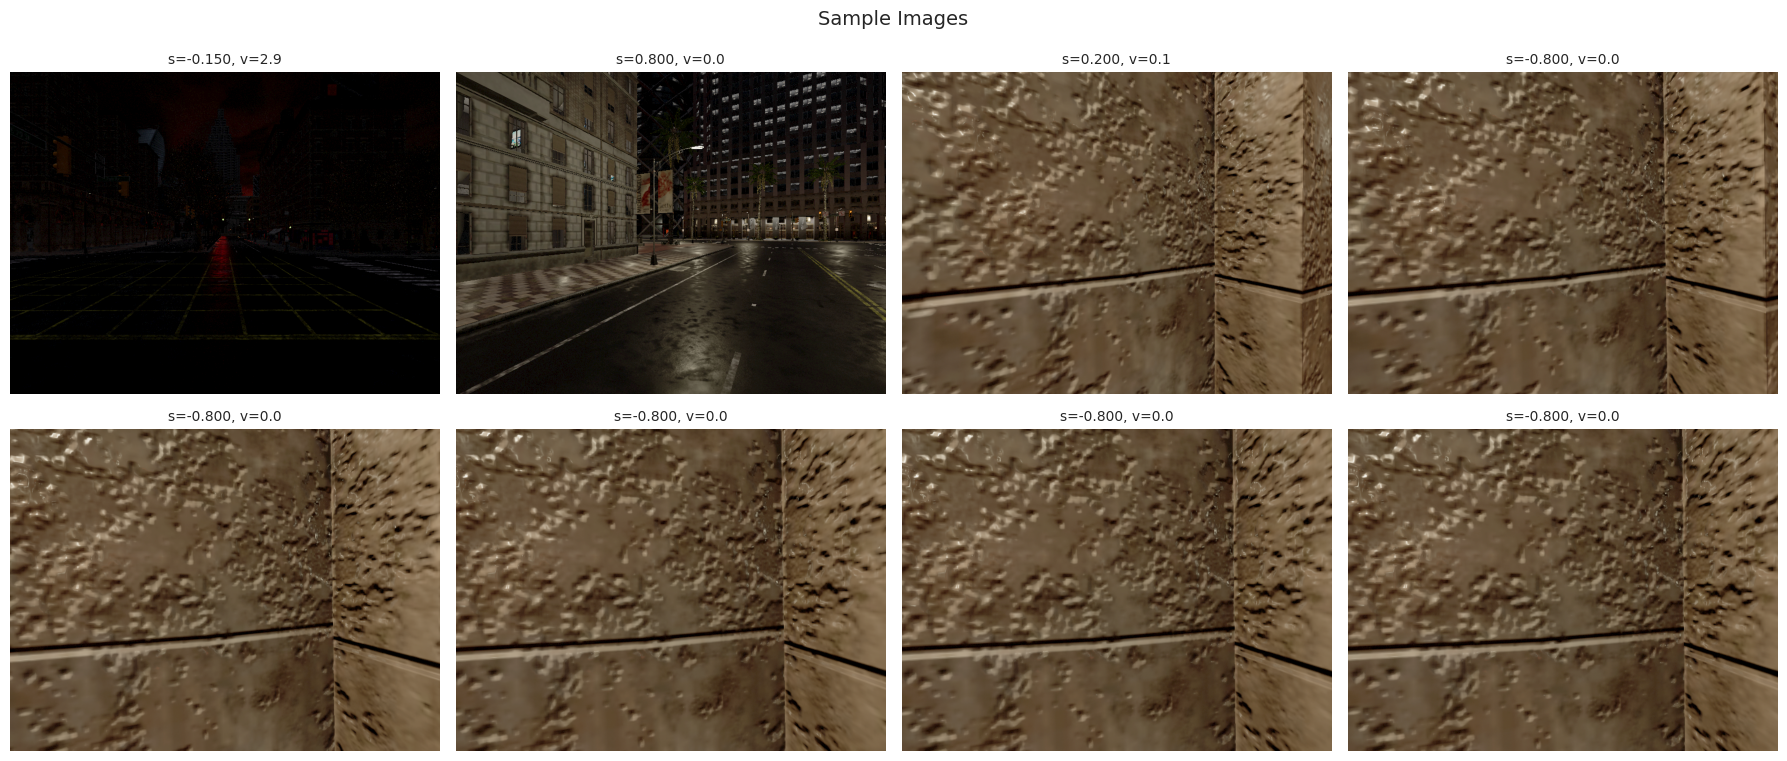

In [19]:
png_files = sorted(images_dir.glob('*.png'))
n_samples = min(8, len(png_files))
if n_samples > 0:
    indices = np.linspace(0, len(png_files)-1, n_samples, dtype=int)
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        img = Image.open(png_files[idx])
        axes[i].imshow(img)
        fname = png_files[idx].name
        row = df[df['image_filename']==fname]
        if len(row)>0:
            axes[i].set_title(f's={row["steering"].values[0]:.3f}, v={row["speed"].values[0]:.1f}', fontsize=10)
        else:
            axes[i].set_title(fname, fontsize=9)
        axes[i].axis('off')
    plt.suptitle('Sample Images', fontsize=14)
    plt.tight_layout()
    plt.show()

In [20]:
print('='*60)
print('  FINAL VERDICT')
print('='*60)
checks = []
cp = report.frame_drop_rate*100
checks.append(('Corrupted', 'PASS' if cp<1 else ('WARN' if cp<5 else 'FAIL'), f'{cp:.1f}%'))
oor = report.out_of_range_steering + report.out_of_range_throttle
checks.append(('Label Range', 'PASS' if oor==0 else ('WARN' if oor<10 else 'FAIL'), f'{oor}'))
checks.append(('Timing', 'PASS' if anomaly_pct<5 else ('WARN' if anomaly_pct<10 else 'FAIL'), f'{anomaly_pct:.1f}%'))
checks.append(('Straight Bias', 'PASS' if straight_pct<50 else ('WARN' if straight_pct<70 else 'FAIL'), f'{straight_pct:.1f}%'))

rdf = pd.DataFrame(checks, columns=['Check','Result','Value'])
display(rdf.style.hide(axis='index'))

if all('PASS' in c[1] for c in checks):
    print('\n>>> ALL PASS - Ready for training')
elif any('FAIL' in c[1] for c in checks):
    print('\n>>> FAIL - Fix issues before training')
else:
    print('\n>>> WARN - Review before proceeding')

  FINAL VERDICT


Check,Result,Value
Corrupted,PASS,0.0%
Label Range,PASS,0
Timing,WARN,6.9%
Straight Bias,PASS,1.0%



>>> WARN - Review before proceeding
